# Figure 6 — Murine efficacy and safety

In vivo *A. baumannii* ATCC 19606 skin-scarification (A, B) and thigh-infection (D, E), plus proteolytic stability of leads (C). Reads the tidy `data/murine_skin.csv`, `data/murine_thigh.csv`, `data/proteolysis.csv`. Renders `../figures/figure6_murine.{pdf,png}`.


In [1]:
# Figure 6 -- murine efficacy + safety. House style (<=6.5x8 in, >=6 pt).
import csv, math, collections
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

DATA = Path("../data")   # reads the built tidy files: murine_skin.csv, murine_thigh.csv, proteolysis.csv

plt.rcParams.update({
    'font.size': 6, 'axes.titlesize': 7, 'axes.labelsize': 6,
    'xtick.labelsize': 6, 'ytick.labelsize': 6, 'legend.fontsize': 6,
    'axes.linewidth': 0.5, 'axes.edgecolor': 'grey',
    'xtick.color': '#555555', 'ytick.color': '#555555', 'axes.labelcolor': '#333333',
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'figure.dpi': 300, 'savefig.dpi': 300,
    'xtick.major.width': 0.6, 'ytick.major.width': 0.6,
    'xtick.major.size': 2, 'ytick.major.size': 2,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
})
PL = dict(fontsize=10, fontweight='bold', va='bottom', ha='left')

# groups per experiment, using canonical short_names (bZIP is a motif design -> Ω-MT-; LPS analogs -> Ω-AMT-)
SKIN  = ['Control','Ω-AT-BoCo1-5','Ω-AT-BoCo1-9','Ω-DP-52','Ω-DP-19','Ω-AMT-cecropin-1','Ω-AMT-cecropin-4','Polymyxin B']
THIGH = ['Control','Ω-MT-bZIP-8','Ω-AMT-pa4-1','Levofloxacin']
# dashboard (Tailwind) palette; a light/dark shade separates the two analogs of a family
COL = {'Control':'#292524',
    'Ω-AT-BoCo1-5':'#6ee7b7','Ω-AT-BoCo1-9':'#065f46',       # BoCo1 (green): light / dark
    'Ω-DP-52':'#a5b4fc','Ω-DP-19':'#3730a3',                 # de novo (indigo): light / dark
    'Ω-AMT-cecropin-1':'#f9a8d4','Ω-AMT-cecropin-4':'#9d174d',# cecropin (pink): light / dark
    'Polymyxin B':'#9ca3af',
    'Ω-MT-bZIP-8':'#3b82f6','Ω-AMT-pa4-1':'#14b8a6','Levofloxacin':'#9ca3af'}  # bZIP blue; pa4 teal
STAB = ['Ω-AP-Mammutin-1-4','Ω-AU-GQ20-4','Ω-MT-bZIP-8','Ω-AMT-pa4-1','Ω-AMT-sarcotoxin-4']
SCOL = {'Ω-AP-Mammutin-1-4':'#e11d48','Ω-AU-GQ20-4':'#f59e0b','Ω-MT-bZIP-8':'#3b82f6',
        'Ω-AMT-pa4-1':'#14b8a6','Ω-AMT-sarcotoxin-4':'#a855f7'}

def load_cfu(tidy_csv, day):
    """{short_name: [log10 CFU g^-1, ...]} for one model + day from data/murine_*.csv."""
    out = collections.defaultdict(list)
    for r in csv.DictReader(open(DATA / tidy_csv)):
        if r['assay'] == 'cfu' and int(float(r['day'])) == day:
            v = float(r['value'])
            if v > 0: out[r['short_name']].append(math.log10(v))
    return out

def load_weight(tidy_csv, groups):
    """(times, {short_name: (mean[], sem[])}) from the weight rows of data/murine_*.csv."""
    rows = [r for r in csv.DictReader(open(DATA / tidy_csv)) if r['assay'] == 'weight']
    times = sorted({int(float(r['day'])) for r in rows})
    stats = {}
    for g in groups:
        m, s = [], []
        for t in times:
            v = [float(r['value']) for r in rows if r['short_name'] == g and int(float(r['day'])) == t]
            m.append(np.mean(v) if v else np.nan)
            s.append(np.std(v) / math.sqrt(len(v)) if len(v) > 1 else 0)
        stats[g] = (np.array(m), np.array(s))
    return np.array(times, float), stats

def boxpanel(ax, tidy_csv, days, groups, sig, ylim, sig_ref=None, ref_group=None):
    """Two day-blocks of box + jitter.
    Solid grey brackets = each treatment vs Control (leftmost box).
    Optional dashed grey brackets (sig_ref) = the sig_ref groups vs the reference
    arm (ref_group); drawn as a lower tier so the two comparison types can't be confused."""
    rng = np.random.RandomState(0); nG = len(groups); block = nG + 1.2
    for di, (day_label, day_int) in enumerate(days):
        cfu = load_cfu(tidy_csv, day_int); x0 = di * block; pos = [x0 + i for i in range(nG)]; block_max = ylim[0]
        for i, g in enumerate(groups):
            vals = cfu.get(g, []); c = COL[g]
            ax.boxplot([vals], positions=[pos[i]], widths=0.62, patch_artist=True, showfliers=False, zorder=2,
                       medianprops=dict(color='#333333', lw=0.7), whiskerprops=dict(color=c, lw=0.8),
                       capprops=dict(color=c, lw=0.8), boxprops=dict(facecolor=c, edgecolor=c, alpha=0.60, lw=0.8))
            ax.scatter(pos[i] + (rng.rand(len(vals)) - 0.5) * 0.28, vals, s=5, color=c, edgecolor='#666', linewidth=0.2, zorder=3)
            if vals: block_max = max(block_max, max(vals))
        base = block_max + 0.4
        # lower tier: selected groups vs the reference arm (dashed, anchored on the reference box)
        if sig_ref and ref_group in groups and cfu.get(ref_group, []):
            rx = pos[groups.index(ref_group)]; rrank = 0
            for i, g in enumerate(groups):
                if g == ref_group or g not in sig_ref.get(day_label, {}) or not cfu.get(g, []): continue
                code = sig_ref[day_label][g]; gx = pos[i]; gy = base + rrank * 0.48
                ax.plot([rx, rx, gx, gx], [gy - 0.11, gy, gy, gy - 0.11], lw=0.5, ls=(0, (2, 1.4)), color='#6b7280', zorder=4)
                ax.text((rx + gx) / 2, gy, code, ha='center', va='center', fontsize=6,
                        color='#6b7280', fontweight='bold' if code != 'ns' else 'normal', zorder=5,
                        bbox=dict(boxstyle='round,pad=0.12', facecolor='white', edgecolor='none'))
                rrank += 1
            if rrank: base = base + rrank * 0.48 + 0.2   # lift the vs-Control tier clear of the dashed tier
        # upper tier: each treatment compared vs Control (leftmost box)
        cx = pos[0]; rank = 0
        for i, g in enumerate(groups):
            if i == 0 or g not in sig[day_label] or not cfu.get(g, []): continue
            code = sig[day_label][g]; gx = pos[i]; gy = base + rank * 0.48
            ax.plot([cx, cx, gx, gx], [gy - 0.11, gy, gy, gy - 0.11], lw=0.5, color='#bbb', zorder=4)
            ax.text((cx + gx) / 2, gy, code, ha='center', va='center', fontsize=6,
                    color='#333', fontweight='bold' if code != 'ns' else 'normal', zorder=5,
                    bbox=dict(boxstyle='round,pad=0.12', facecolor='white', edgecolor='none'))
            rank += 1
        ax.text(x0 + (nG - 1) / 2, ylim[0] - 0.11 * (ylim[1] - ylim[0]), day_label, ha='center', va='top', fontsize=6, fontweight='bold')
    if len(days) > 1: ax.axvline(block - 0.6, ls=(0, (2, 2)), color='#bbb', lw=0.6)
    ax.set_xlim(-0.8, block * len(days) - 0.6); ax.set_ylim(*ylim); ax.set_xticks([])
    ax.set_ylabel(r'log$_{10}$ CFU g$^{-1}$')

def linepanel(ax, times, stats, groups, ylim, xlabel):
    for g in groups:
        m, s = stats[g]
        ax.errorbar(times, m, yerr=s, color=COL[g], lw=0.9, marker='o', ms=2.3, capsize=1.1, elinewidth=0.5)
    ax.set_xlabel(xlabel); ax.set_ylabel('Weight change (%)'); ax.set_ylim(*ylim); ax.set_xlim(times.min(), times.max())

def swatches(groups):
    return [plt.Line2D([0], [0], marker='s', ls='', ms=4, color=COL[g], label=g) for g in groups]

In [2]:
# --- Figure 6 statistics, computed from the tidy CFU data (replaces the GraphPad Prism export) ---
# Omnibus:   Kruskal-Wallis across all groups present in a day-block.
# Pairwise:  exact two-sided Mann-Whitney, each treatment vs Control -> the star codes.
#            No Holm / multiple-comparison correction is applied.
# Reference: each non-reference group vs the reference antibiotic (Polymyxin B for skin,
#            Levofloxacin for thigh). Question answered: is any peptide BETTER (lower CFU)
#            than the antibiotic? diff_vs_ref = median(peptide) - median(antibiotic), so
#            diff < 0 means the peptide leaves a lower burden (better); diff > 0 means higher
#            (worse). Reported as the Hodges-Lehmann median difference + exact rank-based CI.
from scipy.stats import mannwhitneyu, kruskal
from functools import lru_cache

def _stars(p):
    if p < 1e-4: return '****'
    if p < 1e-3: return '***'
    if p < 1e-2: return '**'
    if p < 5e-2: return '*'
    return 'ns'

@lru_cache(maxsize=None)
def _u_pmf(n1, n2):
    """Exact null pmf of the Mann-Whitney U statistic, U in 0..n1*n2 (Mann-Whitney recurrence)."""
    @lru_cache(maxsize=None)
    def f(a, b, u):
        if u < 0: return 0
        if a == 0 or b == 0: return 1 if u == 0 else 0
        return f(a - 1, b, u - b) + f(a, b - 1, u)
    total = math.comb(n1 + n2, n1)
    return tuple(f(n1, n2, u) / total for u in range(n1 * n2 + 1))

def _hl_diff_ci(x, y, alpha=0.05):
    """Hodges-Lehmann median of the n1*n2 pairwise differences (x_i - y_j) and its exact
    Mann-Whitney confidence interval. Bounds are the order statistics D_(c+1) and D_(N-c),
    where c is the largest index with P(U<=c) <= alpha/2; the achieved coverage (the highest
    attainable, e.g. 95.9% for 6 vs 6) is returned rather than a nominal 1-alpha."""
    diffs = sorted(xi - yj for xi in x for yj in y)
    N = len(diffs); n1, n2 = len(x), len(y)
    cdf = np.cumsum(_u_pmf(n1, n2))
    c = int(np.max(np.where(cdf <= alpha / 2)[0]))   # largest index with P(U<=c) <= alpha/2
    point = float(np.median(diffs))
    low, high = diffs[c], diffs[N - 1 - c]           # D_(c+1) and D_(N-c)
    coverage = 1.0 - 2.0 * float(cdf[c])
    return point, low, high, coverage

# one entry per day-block: (model, tidy csv, group order, day label, day int, reference arm)
_BLOCKS = [('skin',  'murine_skin.csv',  SKIN,  'Day 2', 2, 'Polymyxin B'),
           ('skin',  'murine_skin.csv',  SKIN,  'Day 4', 4, 'Polymyxin B'),
           ('thigh', 'murine_thigh.csv', THIGH, 'Day 6', 6, 'Levofloxacin'),
           ('thigh', 'murine_thigh.csv', THIGH, 'Day 8', 8, 'Levofloxacin')]
# peptide groups that carry the dashed vs-reference bracket tier in each panel (the ones the
# manuscript positions against the antibiotic): cecropins in panel A, both leads in panel D.
_REF_TIER = {'skin':  {'Ω-AMT-cecropin-1', 'Ω-AMT-cecropin-4'},
             'thigh': {'Ω-MT-bZIP-8', 'Ω-AMT-pa4-1'}}

_omnibus = {}                       # day_label -> (H, p, k, N)
_rows = []                          # flat source-data records
PA, PD = {}, {}                     # vs-Control star codes: skin (panel A), thigh (panel D)
_ref_codes = {'skin': {}, 'thigh': {}}   # vs-reference star codes, per model
for model, csvf, groups, day_label, day_int, ref in _BLOCKS:
    cfu = load_cfu(csvf, day_int)
    present = [g for g in groups if cfu.get(g)]
    H, p_omni = kruskal(*[cfu[g] for g in present])
    _omnibus[day_label] = (H, p_omni, len(present), sum(len(cfu[g]) for g in present))
    ctrl = cfu['Control']; ref_vals = cfu.get(ref, [])
    vs_ctrl, vs_ref = {}, {}
    for g in present:
        if g == 'Control': continue
        _, p_c = mannwhitneyu(cfu[g], ctrl, alternative='two-sided', method='exact')
        vs_ctrl[g] = _stars(p_c)
        rec = dict(model=model, day=day_int, group=g,
                   delta_log10_vs_control=round(float(np.median(cfu[g]) - np.median(ctrl)), 3),
                   p_vs_control=p_c, diff_vs_ref=None, ci_low=None, ci_high=None,
                   ci_conf=None, p_vs_ref=None)
        if g != ref and ref_vals:   # compute vs-reference for every non-reference group
            _, p_r = mannwhitneyu(cfu[g], ref_vals, alternative='two-sided', method='exact')
            d, lo, hi, cov = _hl_diff_ci(cfu[g], ref_vals)
            rec.update(diff_vs_ref=round(d, 3), ci_low=round(lo, 3), ci_high=round(hi, 3),
                       ci_conf=round(cov, 4), p_vs_ref=p_r)
            if g in _REF_TIER[model]: vs_ref[g] = _stars(p_r)
        _rows.append(rec)
    (PA if model == 'skin' else PD)[day_label] = vs_ctrl
    if vs_ref: _ref_codes[model][day_label] = vs_ref
PA_REF = _ref_codes['skin']    # cecropins vs Polymyxin B (panel A dashed tier)
PD_REF = _ref_codes['thigh']   # bZIP-8 / pa4-1 vs Levofloxacin (panel D dashed tier)

def source_data_table():
    """(columns, rows) source-data table backing Figure 6A/6D; one row per treatment x day-block.
    diff_vs_ref < 0 => peptide is better (lower CFU) than the reference antibiotic; > 0 => worse."""
    cols = ['model', 'day', 'group', 'delta_log10_vs_control', 'p_vs_control',
            'diff_vs_ref', 'ci_low', 'ci_high', 'ci_conf', 'p_vs_ref']
    return cols, [[r[c] for c in cols] for r in _rows]

def omnibus_text():
    """One Kruskal-Wallis line per day-block, for the figure legend / caption."""
    return [f"{model} {day_label}: Kruskal-Wallis H={_omnibus[day_label][0]:.1f}, "
            f"p={_omnibus[day_label][1]:.1e} (k={_omnibus[day_label][2]}, N={_omnibus[day_label][3]})"
            for model, _, _, day_label, _, _ in _BLOCKS]

def better_than_reference():
    """Peptide x day-block records where the peptide is significantly BETTER (lower CFU) than
    its reference antibiotic: diff_vs_ref < 0 and p_vs_ref < 0.05."""
    return [r for r in _rows if r['p_vs_ref'] is not None and r['diff_vs_ref'] < 0 and r['p_vs_ref'] < 0.05]

# --- verification print-out (checked against the independently-derived reference values) ---
print("Kruskal-Wallis omnibus:")
for line in omnibus_text(): print("   " + line)
print("\nvs Control (exact two-sided Mann-Whitney):")
for r in _rows:
    print(f"   {r['model']:5s} d{r['day']} {r['group']:20s} p={r['p_vs_control']:.6f}  {_stars(r['p_vs_control'])}")
print("\nvs reference antibiotic (Hodges-Lehmann median diff + exact rank-based CI; diff<0 = peptide better):")
for r in _rows:
    if r['p_vs_ref'] is None: continue
    print(f"   {r['model']:5s} d{r['day']} {r['group']:18s} diff={r['diff_vs_ref']:+.2f}  "
          f"CI[{r['ci_low']:+.2f}, {r['ci_high']:+.2f}] ({r['ci_conf']*100:.1f}%)  "
          f"p={r['p_vs_ref']:.3f}  {_stars(r['p_vs_ref'])}")
_better = better_than_reference()
print("\nIs any peptide significantly BETTER (lower CFU) than its reference antibiotic?")
if _better:
    for r in _better:
        print(f"   YES: {r['model']} d{r['day']} {r['group']} diff={r['diff_vs_ref']:+.2f} p={r['p_vs_ref']:.3f}")
else:
    print("   No: the best peptides only match the antibiotic (ns); none reaches a significant"
          " negative difference. Positive/significant entries are peptides WORSE than the reference.")

Kruskal-Wallis omnibus:
   skin Day 2: Kruskal-Wallis H=37.4, p=4.0e-06 (k=8, N=48)
   skin Day 4: Kruskal-Wallis H=39.7, p=1.4e-06 (k=8, N=48)
   thigh Day 6: Kruskal-Wallis H=18.8, p=3.0e-04 (k=4, N=24)
   thigh Day 8: Kruskal-Wallis H=19.4, p=2.2e-04 (k=4, N=24)

vs Control (exact two-sided Mann-Whitney):
   skin  d2 Ω-AT-BoCo1-5         p=0.002165  **
   skin  d2 Ω-AT-BoCo1-9         p=0.025974  *
   skin  d2 Ω-DP-52              p=0.002165  **
   skin  d2 Ω-DP-19              p=0.002165  **
   skin  d2 Ω-AMT-cecropin-1     p=0.002165  **
   skin  d2 Ω-AMT-cecropin-4     p=0.002165  **
   skin  d2 Polymyxin B          p=0.002165  **
   skin  d4 Ω-AT-BoCo1-5         p=0.002165  **
   skin  d4 Ω-AT-BoCo1-9         p=0.002165  **
   skin  d4 Ω-DP-52              p=0.002165  **
   skin  d4 Ω-DP-19              p=0.002165  **
   skin  d4 Ω-AMT-cecropin-1     p=0.002165  **
   skin  d4 Ω-AMT-cecropin-4     p=0.002165  **
   skin  d4 Polymyxin B          p=0.002165  **
   thigh d6 Ω-MT-bZ

saved ../figures/figure6_murine.{pdf,png}


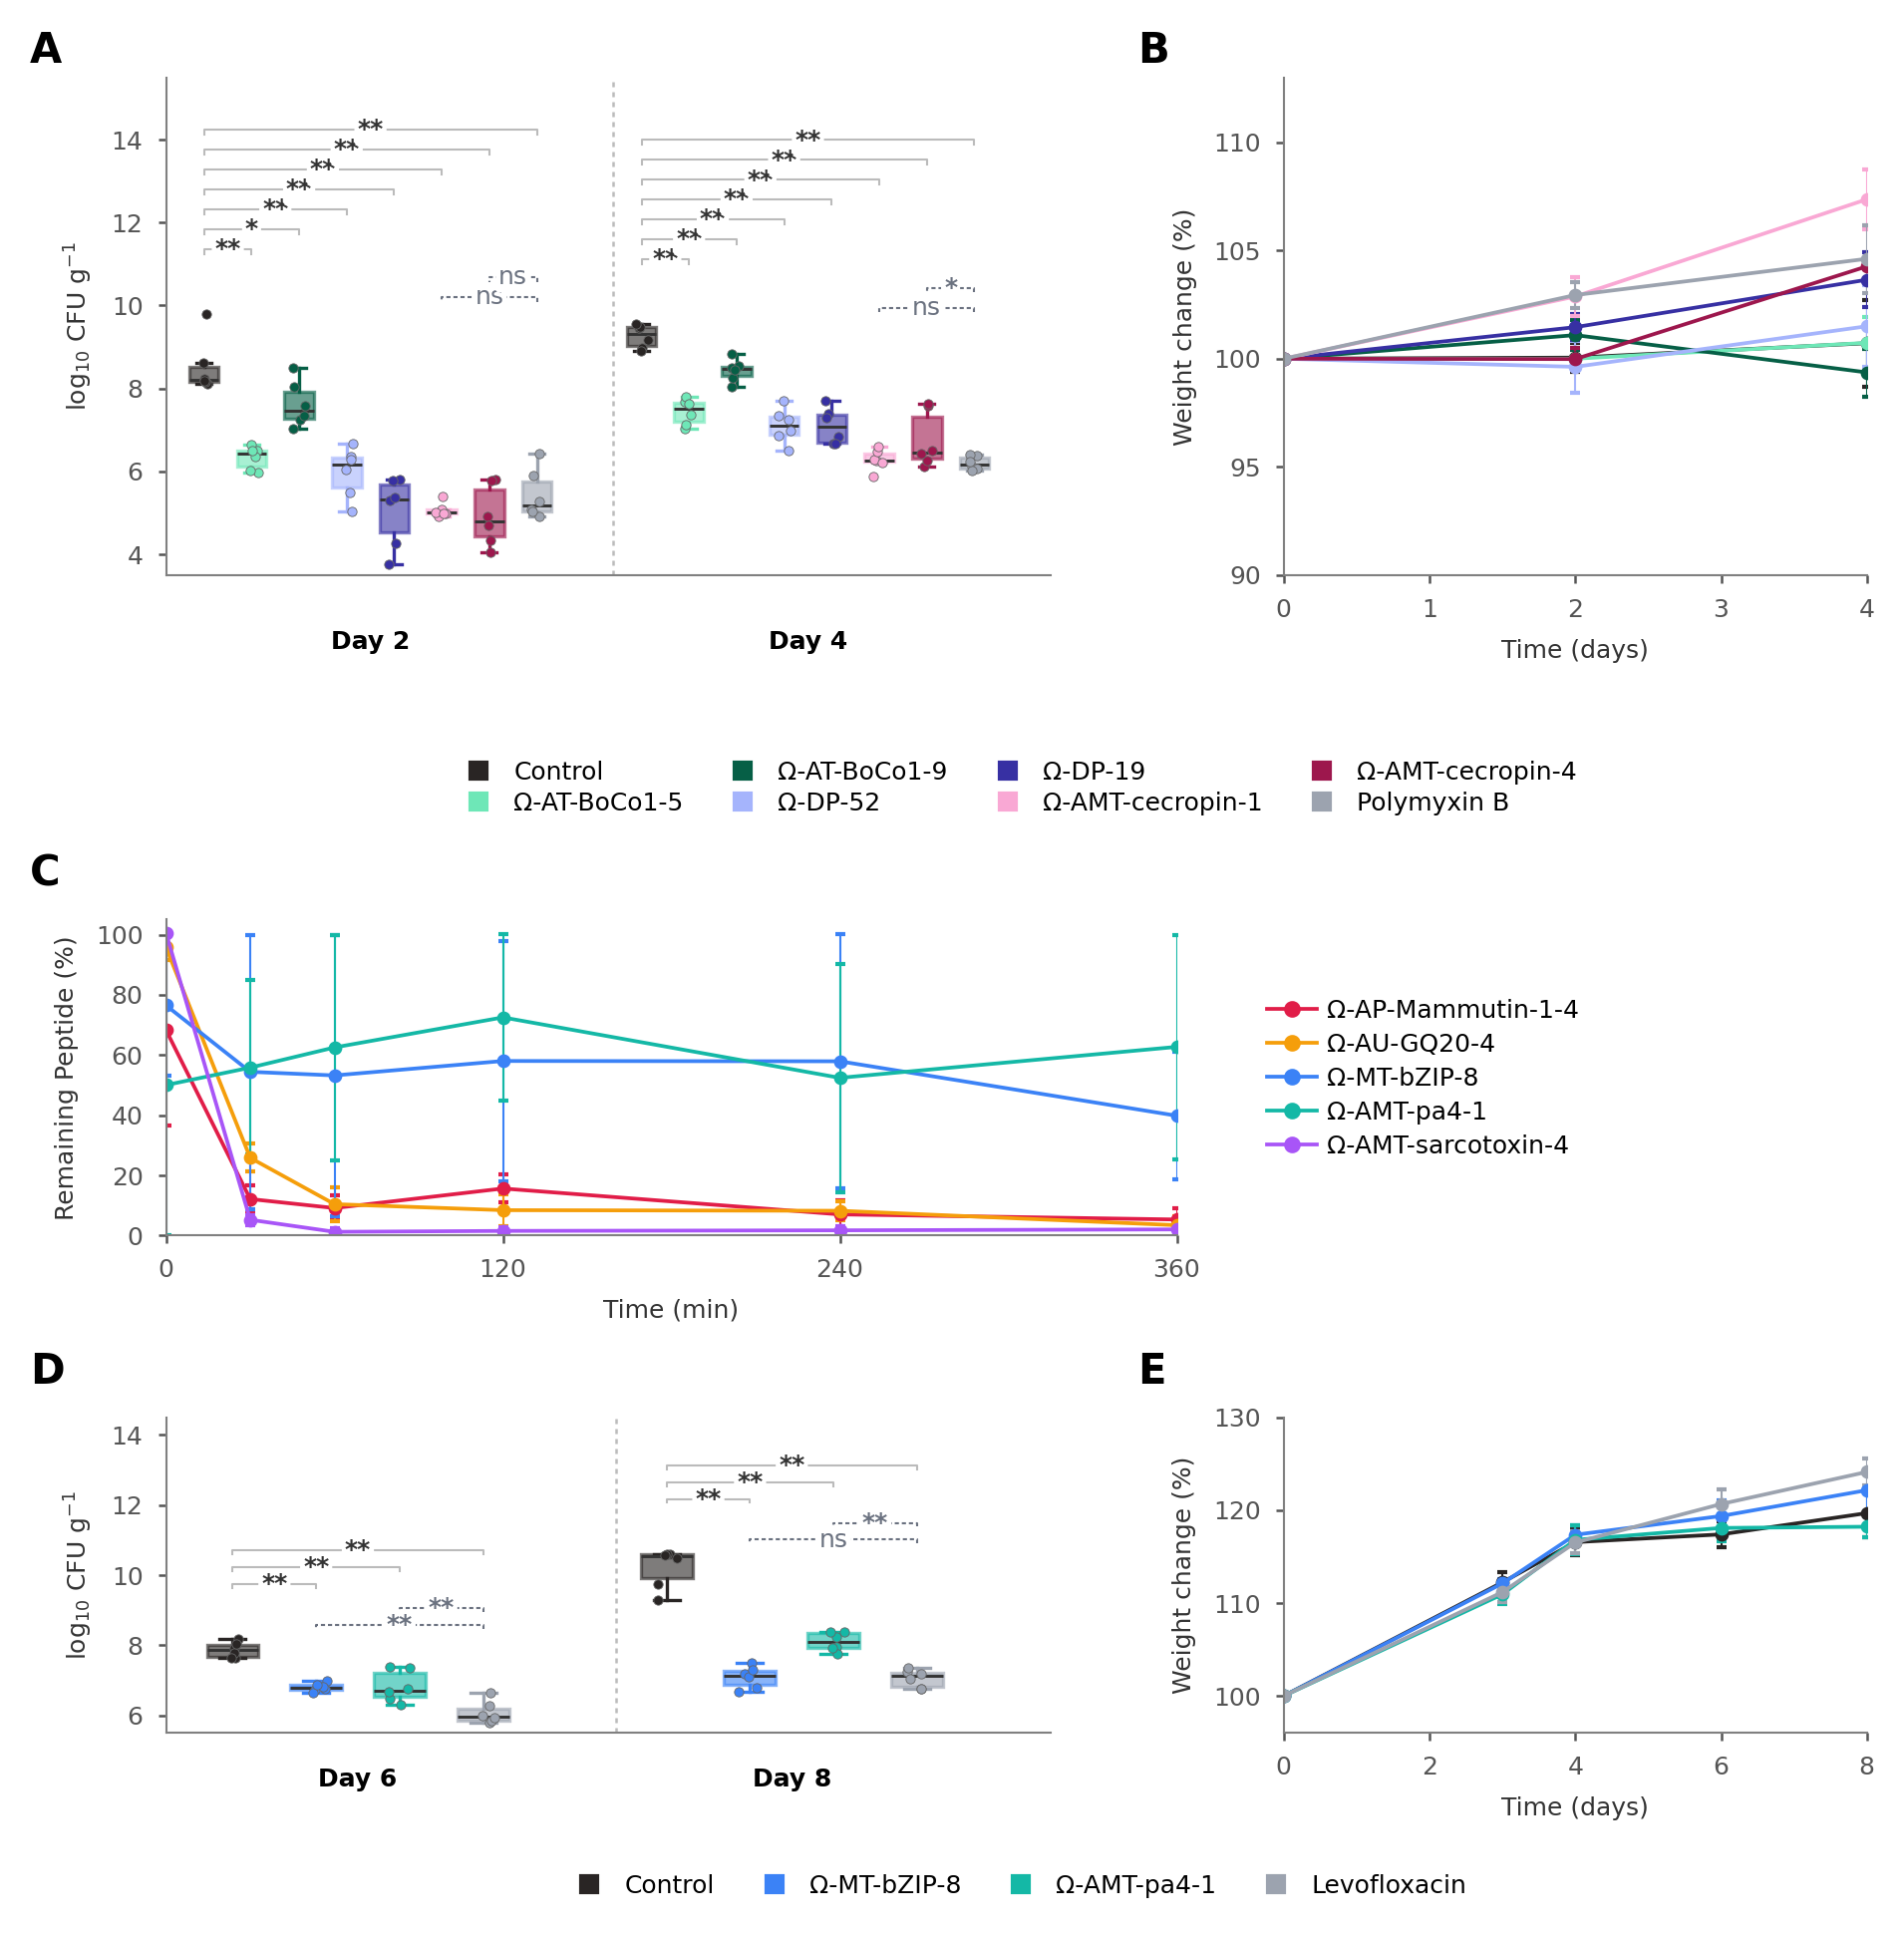

In [3]:
# Figure 6: A|B (skin, shared legend below), C (stability, legend right), D|E (thigh, shared legend below)
fig = plt.figure(figsize=(6.5, 6.4))
axA = fig.add_axes([0.085, 0.715, 0.455, 0.260])   # skin CFU
axB = fig.add_axes([0.660, 0.715, 0.300, 0.260])   # skin weight
axC = fig.add_axes([0.085, 0.370, 0.520, 0.165])   # stability
axD = fig.add_axes([0.085, 0.110, 0.455, 0.165])   # thigh CFU
axE = fig.add_axes([0.660, 0.110, 0.300, 0.165])   # thigh weight

# Row 1: A | B (skin) + shared legend below. Panel A carries a second, dashed bracket tier
# (PA_REF) comparing the two cecropin analogs vs Polymyxin B; ylim raised to clear it.
boxpanel(axA, "murine_skin.csv", [('Day 2', 2), ('Day 4', 4)], SKIN, PA, (3.5, 15.5),
         sig_ref=PA_REF, ref_group='Polymyxin B')
tB, sB = load_weight("murine_skin.csv", SKIN)
linepanel(axB, tB, sB, SKIN, (90, 113), 'Time (days)')
fig.text(0.015, 0.978, 'A', **PL); fig.text(0.585, 0.978, 'B', **PL)
fig.legend(handles=swatches(SKIN), loc='upper center', bbox_to_anchor=(0.522, 0.630), frameon=False,
           handletextpad=0.4, labelspacing=0.3, ncol=4, columnspacing=1.4)

# Row 2: C (stability, data/proteolysis.csv), legend to the right
_pro = collections.defaultdict(list)
for row in csv.DictReader(open(DATA / "proteolysis.csv")):
    _pro[row['short_name']].append((float(row['time_min']), float(row['rep1']), float(row['rep2']), float(row['mean'])))
for p in STAB:
    rec = sorted(_pro[p]); t = np.array([x[0] for x in rec]); m = np.array([x[3] for x in rec])
    err = np.array([abs(x[1] - x[2]) / 2 for x in rec])
    axC.errorbar(t, m, yerr=err, color=SCOL[p], lw=0.9, marker='o', ms=2.3, capsize=1.1, elinewidth=0.5)
axC.set_xlabel('Time (min)'); axC.set_ylabel('Remaining Peptide (%)'); axC.set_ylim(0, 105); axC.set_xlim(0, 360); axC.set_xticks([0, 120, 240, 360])
hC = [plt.Line2D([0], [0], marker='o', ls='-', lw=0.9, ms=3, color=SCOL[p], label=p) for p in STAB]
fig.legend(handles=hC, loc='center left', bbox_to_anchor=(0.640, 0.452), frameon=False, handletextpad=0.4, labelspacing=0.4)
fig.text(0.015, 0.548, 'C', **PL)

# Row 3: D | E (thigh) + shared legend below. Panel D carries the same dashed vs-reference tier
# (PD_REF) comparing bZIP-8 / pa4-1 vs Levofloxacin; ylim raised to clear it.
boxpanel(axD, "murine_thigh.csv", [('Day 6', 6), ('Day 8', 8)], THIGH, PD, (5.5, 14.5),
         sig_ref=PD_REF, ref_group='Levofloxacin')
tE, sE = load_weight("murine_thigh.csv", THIGH)
linepanel(axE, tE, sE, THIGH, (96, 130), 'Time (days)')
fig.text(0.015, 0.288, 'D', **PL); fig.text(0.585, 0.288, 'E', **PL)
fig.legend(handles=swatches(THIGH), loc='upper center', bbox_to_anchor=(0.522, 0.048), frameon=False,
           handletextpad=0.4, labelspacing=0.3, ncol=4, columnspacing=1.4)

import os; os.makedirs("../figures", exist_ok=True)
fig.savefig("../figures/figure6_murine.pdf", bbox_inches='tight')
fig.savefig("../figures/figure6_murine.png", dpi=200, bbox_inches='tight')
print("saved ../figures/figure6_murine.{pdf,png}")